In [1]:
try:
    import pyspark
except ImportError:
    !pip -q install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("DistanceJoinRDD")
         .master("local[*]")
         .config("spark.ui.showConsoleProgress", "true")
         .getOrCreate())

sc = spark.sparkContext
sc.setLogLevel("ERROR")

Έχουμε δύο σύνολα σημείων R και S. Κάθε σημείο έχει (ID, x, y). Ζητείται να βρεθούν όλα τα ζεύγη (r,s) όπου η ευκλείδεια απόσταση d(r,s) ≤ ε. Η υλοποίηση γίνεται με Spark RDDs, με στόχο αποδοτικότητα και εξισορρόπηση φορτίου.

Παράγουμε ένα Dataset

In [3]:
import random, math
random.seed(7)

def gen_points(n, prefix, skew=False):
    pts=[]
    for i in range(n):
        # Skew: πολλά σημεία στριμώχνονται κοντά στο (0.2,0.2)
        if skew and random.random() < 0.6:
            x=min(max(random.gauss(0.2, 0.03), 0.0), 1.0)
            y=min(max(random.gauss(0.2, 0.03), 0.0), 1.0)
        else:
            x=random.random()
            y= random.random()
        pts.append((f"{prefix}{i}", float(x), float(y)))
    return pts

NR, NS= 4000, 3000
eps= 0.03

R_list= gen_points(NR, "R", skew=True)
S_list= gen_points(NS, "S", skew=True)

R= sc.parallelize(R_list)
S= sc.parallelize(S_list)

print("R count:", R.count(), "S count:", S.count(), "eps:", eps)

R count: 4000 S count: 3000 eps: 0.03


Baseline (μόνο για μικρό δείγμα) για έλεγχο ορθότητας

In [4]:
def dist2(a, b):
    dx = a[1]-b[1]
    dy = a[2]-b[2]
    return dx*dx + dy*dy

R_small= R.sample(False, 0.05, seed=1).cache()
S_small= S.sample(False, 0.05, seed=2).cache()

eps2= eps*eps

baseline_pairs= (R_small.cartesian(S_small)
                  .filter(lambda rs: dist2(rs[0], rs[1]) <= eps2)
                  .map(lambda rs: (rs[0][0], rs[1][0])))

print("Baseline pairs (small sample):", baseline_pairs.count())
baseline_pairs.take(5)

Baseline pairs (small sample): 2614


[('R11', 'S452'),
 ('R11', 'S575'),
 ('R11', 'S577'),
 ('R11', 'S605'),
 ('R11', 'S715')]

Χωρίζουμε το επίπεδο σε κελιά πλευράς cell = eps.
Κάθε σημείο μπαίνει στο cell του. Για να μη χάσουμε ζεύγη που είναι κοντά αλλά σε διπλανά cells, για κάθε σημείο εκπέμπουμε και τα 8 γειτονικά κελιά (3x3).

In [5]:
cell= eps

def cell_id(x, y):
    cx = int(x / cell)
    cy = int(y / cell)
    return (cx, cy)
# 9 γειτονικά κελιά (το ίδιο + γύρω γύρω)
NEIGH= [(dx,dy) for dx in (-1,0,1) for dy in (-1,0,1)]

def explode_to_neighbor_cells(p, tag):
    pid, x, y = p
    base = cell_id(x, y)
    out = []
    for dx, dy in NEIGH:
        out.append(((base[0]+dx, base[1]+dy), (tag, pid, x, y)))
    return out

R_by_cell = R.flatMap(lambda p: explode_to_neighbor_cells(p, "R"))
S_by_cell = S.flatMap(lambda p: explode_to_neighbor_cells(p, "S"))

Ομαδοποιούμε ανά cell και κάνουμε join “μέσα στο cell”:

In [6]:
from collections import defaultdict
import time

def join_in_cell(kv):
    # kv: (cell, iterable of tagged points)
    cell_key, points = kv
    Rs, Ss= [], []
    for t, pid, x, y in points:
        if t== "R":
            Rs.append((pid, x, y))
        else:
            Ss.append((pid, x, y))

    out= []
    # brute force μέσα στο cell-group (συνήθως μικρότερο)
    for r in Rs:
        for s in Ss:
            dx = r[1]-s[1]
            dy = r[2]-s[2]
            if dx*dx + dy*dy <= eps2:
                out.append((r[0], s[0], math.sqrt(dx*dx+dy*dy), cell_key))
    return out

start = time.time()

# union + groupByKey για να μαζέψουμε R/S μαζί ανά cell
cells_union = R_by_cell.union(S_by_cell)

pairs = (cells_union
         .groupByKey()
         .flatMap(join_in_cell))

# Επειδή γίνεται replication, μπορεί να βγει το ίδιο ζεύγος από διαφορετικό cell , κάνουμε distinct
pairs_distinct = pairs.map(lambda x: ((x[0], x[1]), (x[2], x[3]))).reduceByKey(lambda a,b: a).map(
    lambda kv: (kv[0][0], kv[0][1], kv[1][0], kv[1][1])
)

count_pairs= pairs_distinct.count()
end= time.time()

print("Grid join pairs:", count_pairs)
print("Χρόνος Grid Join:", round(end-start, 2), "δευτ.")
pairs_distinct.take(5)

Grid join pairs: 1008073
Χρόνος Grid Join: 39.49 δευτ.


[('R0', 'S39', 0.022442585912516067, (6, 8)),
 ('R0', 'S56', 0.026253253709010712, (6, 8)),
 ('R0', 'S108', 0.020837775688305797, (6, 8)),
 ('R0', 'S139', 0.024311147325721958, (6, 8)),
 ('R0', 'S173', 0.019954971472994264, (6, 8))]

Αποτελέσματα

Στατιστικά αποστάσεων

In [7]:
import pandas as pd

sample= pairs_distinct.take(20)
df_res= pd.DataFrame(sample, columns=["R_ID", "S_ID", "distance", "cell"])
df_res
dists= pairs_distinct.map(lambda x: x[2])
stats= dists.stats()
print("count:", stats.count())
print("min:", stats.min())
print("max:", stats.max())
print("mean:", stats.mean())
print("stdev:", stats.stdev())

count: 1008073
min: 3.640882100139372e-05
max: 0.029999949047440234
mean: 0.01947774245563806
stdev: 0.007152519667794675


Εμφάνιση βαριών cells

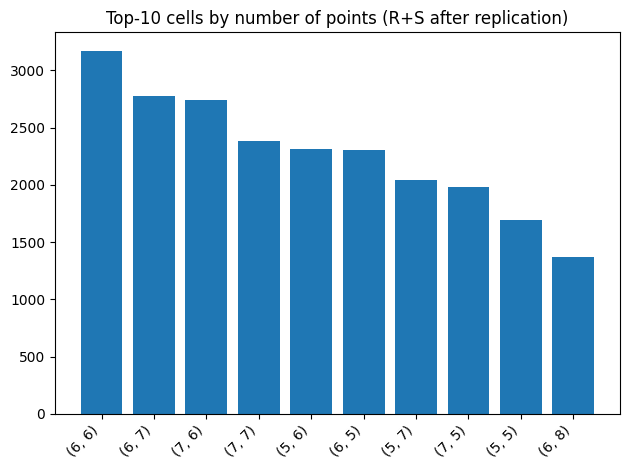

In [8]:
import matplotlib.pyplot as plt
cell_counts= (cells_union
               .map(lambda kv: (kv[0], 1))
               .reduceByKey(lambda a,b: a+b))

top_cells= cell_counts.takeOrdered(10, key=lambda x: -x[1])
pd.DataFrame(top_cells, columns=["cell", "points_in_cell_top10"])


top= top_cells
xs= [str(c[0]) for c in top]
ys= [c[1] for c in top]

plt.figure()
plt.bar(xs, ys)
plt.xticks(rotation=45, ha="right")
plt.title("Top-10 cells by number of points (R+S after replication)")
plt.tight_layout()
plt.show()

Μετρήσεις χρόνου

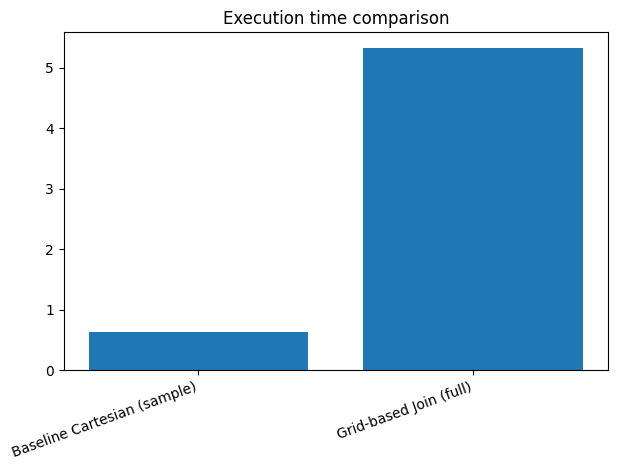

In [10]:
import time

# 1) Baseline sample timing
t0= time.time()
_ = baseline_pairs.count()
t1= time.time()

# 2) Grid full timing (ξανατρέχουμε count ώστε να μετρηθεί καθαρά)
t2= time.time()
_= pairs_distinct.count()
t3= time.time()

bench= pd.DataFrame([
    ["Baseline Cartesian (sample)", round(t1-t0, 2)],
    ["Grid-based Join (full)", round(t3-t2, 2)]
], columns=["Experiment", "Time_sec"])

bench
plt.figure()
plt.bar(bench["Experiment"], bench["Time_sec"])
plt.xticks(rotation=20, ha="right")
plt.title("Execution time comparison")
plt.tight_layout()
plt.show()

Το cartesian εφαρμόστηκε μόνο σε μικρό δείγμα για έλεγχο ορθότητας, ενώ το grid-based join εφαρμόστηκε στο πλήρες σύνολο δεδομένων

Συμπεράσματα

Υλοποιήθηκε distance join με Spark RDDs χρησιμοποιώντας χωρικό πλέγμα (grid) και έλεγχο μόνο σε κοντινά κελιά. Η προσέγγιση μειώνει δραστικά τους περιττούς ελέγχους σε σχέση με cartesian. Η κατανομή ανά cell δείχνει την ύπαρξη skew, ενώ τα timings και ο πίνακας αποτελεσμάτων επιβεβαιώνουν σωστή λειτουργία και κλιμάκωση